In [1]:
# ============================================================
# H2 - VISIT DISPOSITION vs REPORTED MEDIAN ED LENGTH OF STAY
# ============================================================
# Research question : Does reported median ED LOS differ between admitted and non-admitted visits?
# Null hypothesis   : Median LOS is equal for admitted and non-admitted visits.
# Alternative       : Median LOS differs between admitted and non-admitted visits.
# Method            : Frequency-weighted Mann-Whitney U test
#
# Rows are aggregates: ed_visits is a frequency weight, not a covariate.
#
# The test itself is NOT reimplemented here. It is imported from
# backend.analytics.statistics.weighted, the same engine the API serves, so this
# notebook and the production endpoint cannot report different numbers.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Resolve the project root so the notebook runs from any working directory.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "backend").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "Explorer Dataset"
CLEAN_DIR = RAW_DIR / "cleaned"
WORKBOOK = PROJECT_ROOT / "data" / "cleaned dataset" / "Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"

ALPHA = 0.05

print("Project root :", PROJECT_ROOT)
print("Alpha        :", ALPHA)

Project root : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-
Alpha        : 0.05


In [3]:
# Prefer the cleaned copy written by data/Explorer Dataset/Explorer_Dataset_Cleaning.ipynb.
SOURCE = CLEAN_DIR / "Visit_Disposition.csv"

if not SOURCE.exists():
    SOURCE = RAW_DIR / "Visit_Disposition.csv"

df = pd.read_csv(SOURCE)

print("Source file :", SOURCE.relative_to(PROJECT_ROOT))
print("Shape       :", df.shape)
print("Cleaned copy:", SOURCE.parent == CLEAN_DIR)

Source file : data\Explorer Dataset\cleaned\Visit_Disposition.csv
Shape       : (936, 13)
Cleaned copy: True


In [4]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi,is_suppressed
0,2021-2022,2021,Female,Admitted,1,Admitted,0-19,Pediatric & Youth,61448,450.0,7.5,27651600,0
1,2021-2022,2021,Female,Admitted,1,Admitted,20-44,Young Adult,135970,702.0,11.7,95450940,0
2,2021-2022,2021,Female,Admitted,1,Admitted,45-64,Middle Adult,154636,792.0,13.2,122471712,0
3,2021-2022,2021,Female,Admitted,1,Admitted,65+,Older Adult,423379,966.0,16.1,408984114,0
4,2021-2022,2021,Male,Admitted,1,Admitted,0-19,Pediatric & Youth,61089,420.0,7.0,25657380,0
5,2021-2022,2021,Male,Admitted,1,Admitted,20-44,Young Adult,135841,720.0,12.0,97805520,0
6,2021-2022,2021,Male,Admitted,1,Admitted,45-64,Middle Adult,197560,762.0,12.7,150540720,0
7,2021-2022,2021,Male,Admitted,1,Admitted,65+,Older Adult,403171,906.0,15.1,365272926,0
8,2021-2022,2021,Female,Death,0,Not Admitted,0-19,Pediatric & Youth,176,36.0,0.6,6336,0
9,2021-2022,2021,Female,Death,0,Not Admitted,20-44,Young Adult,452,42.0,0.7,18984,0


In [5]:
print("COLUMN NAMES AND TYPES")
print("-" * 80)

display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": [int(df[c].isna().sum()) for c in df.columns],
}))

COLUMN NAMES AND TYPES
--------------------------------------------------------------------------------


,Column,Data_Type,Missing
0,fiscal_year,str,0
1,fiscal_year_start,int64,0
2,sex,str,0
3,visit_disposition,str,0
4,admission_flag,int64,0
5,admission_status,str,0
6,age_group,str,0
7,population_category,str,0
8,ed_visits,int64,0
9,median_los_minutes,float64,0


In [6]:
print("DATA QUALITY CHECKS")
print("-" * 80)

print(f"Rows              : {len(df):,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Total missing     : {df.isna().sum().sum():,}")

if "ed_visits" in df.columns:
    print(f"ED visits <= 0    : {(df['ed_visits'] <= 0).sum():,}")
    print(f"Total ED visits   : {df['ed_visits'].sum():,.0f}")

if "median_los_minutes" in df.columns:
    print(f"LOS < 0           : {(df['median_los_minutes'] < 0).sum():,}")

DATA QUALITY CHECKS
--------------------------------------------------------------------------------
Rows              : 936
Duplicate rows    : 0
Total missing     : 0
ED visits <= 0    : 0
Total ED visits   : 175,762,944
LOS < 0           : 0


In [7]:
from backend.analytics.statistics.weighted import (
    weighted_mann_whitney_u,
    weighted_mean,
    weighted_median,
)

print("Weighted engine imported from backend.analytics.statistics.weighted")

Weighted engine imported from backend.analytics.statistics.weighted


In [8]:
print("VISIT DISPOSITION CATEGORIES")
print("-" * 80)

disposition_summary = (
    df.groupby(["visit_disposition", "admission_flag"], dropna=False)["ed_visits"]
    .agg(["count", "sum"])
    .reset_index()
    .rename(columns={"count": "records", "sum": "total_ed_visits"})
    .sort_values("total_ed_visits", ascending=False)
)

display(disposition_summary)

VISIT DISPOSITION CATEGORIES
--------------------------------------------------------------------------------


,visit_disposition,admission_flag,records,total_ed_visits
2,Discharged,0,152,145245540
0,Admitted,1,152,18004220
4,Left Without Being Seen,0,152,8492360
5,Transferred,0,152,2786266
3,Intra-Facility Transfer,0,152,909384
1,Death,0,152,182003
6,Unknown,0,24,143171


In [9]:
# admission_flag is the grouping variable: 1 = admitted, 0 = every other disposition.
# "Unknown" carries no disposition information and is excluded.
h2_df = df.dropna(subset=["visit_disposition", "ed_visits", "median_los_minutes", "admission_flag"]).copy()
h2_df = h2_df[(h2_df["ed_visits"] > 0) & (h2_df["median_los_minutes"] >= 0)]
h2_df = h2_df[h2_df["visit_disposition"].astype(str).str.strip() != "Unknown"]

admitted = h2_df[h2_df["admission_flag"] == 1]
non_admitted = h2_df[h2_df["admission_flag"] == 0]

print("H2 ANALYSIS DATASET")
print("=" * 80)
print(f"Original records        : {len(df):,}")
print(f"Records after filtering : {len(h2_df):,}")
print()
print(f"Admitted     : {len(admitted):>4,} records   {admitted['ed_visits'].sum():>14,.0f} visits")
print(f"Non-Admitted : {len(non_admitted):>4,} records   {non_admitted['ed_visits'].sum():>14,.0f} visits")
print()
print("Dispositions treated as non-admitted:")
for d in sorted(non_admitted["visit_disposition"].unique()):
    print("  -", d)

H2 ANALYSIS DATASET
Original records        : 936
Records after filtering : 912

Admitted     :  152 records       18,004,220 visits
Non-Admitted :  760 records      157,615,553 visits

Dispositions treated as non-admitted:
  - Death
  - Discharged
  - Intra-Facility Transfer
  - Left Without Being Seen
  - Transferred


In [10]:
a_vals = admitted["median_los_minutes"].tolist()
a_wts = admitted["ed_visits"].tolist()
n_vals = non_admitted["median_los_minutes"].tolist()
n_wts = non_admitted["ed_visits"].tolist()

h2_summary = pd.DataFrame([
    {
        "group": "Admitted",
        "records": len(a_vals),
        "total_ed_visits": int(sum(a_wts)),
        "weighted_mean_los_minutes": round(weighted_mean(a_vals, a_wts), 2),
        "weighted_median_los_minutes": round(weighted_median(a_vals, a_wts), 2),
        "minimum_los_minutes": min(a_vals),
        "maximum_los_minutes": max(a_vals),
    },
    {
        "group": "Non-Admitted",
        "records": len(n_vals),
        "total_ed_visits": int(sum(n_wts)),
        "weighted_mean_los_minutes": round(weighted_mean(n_vals, n_wts), 2),
        "weighted_median_los_minutes": round(weighted_median(n_vals, n_wts), 2),
        "minimum_los_minutes": min(n_vals),
        "maximum_los_minutes": max(n_vals),
    },
])

display(h2_summary)

,group,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,Admitted,152,18004220,610.84,636.0,235.0,966.0
1,Non-Admitted,760,157615553,155.25,150.0,20.0,384.0


In [11]:
h2_result = weighted_mann_whitney_u(
    a_vals, n_vals, a_wts, n_wts,
    label_a="Admitted", label_b="Non-Admitted",
)

print("H2 - WEIGHTED MANN-WHITNEY U TEST")
print("-" * 80)
print(f"U statistic            : {h2_result['u_statistic']:,.4f}")
print(f"Z score                : {h2_result['z_score']:.6f}")
print(f"P-value                : {h2_result['p_value']:.10f}")
print(f"Total frequency weight : {h2_result['weighted_n']:,}")
print(f"Tie correction         : {h2_result['tie_correction']:.10f}")

H2 - WEIGHTED MANN-WHITNEY U TEST
--------------------------------------------------------------------------------
U statistic            : 2,689,068,488,900.0000
Z score                : 6952.461229
P-value                : 0.0000000000
Total frequency weight : 175,619,773
Tie correction         : 0.9990709839


In [12]:
p_value = h2_result["p_value"]

print("=" * 80)
print("H2 HYPOTHESIS DECISION")
print("=" * 80)
print("Significance level (alpha):", ALPHA)
print(f"P-value: {p_value:.10f}")
print()

if p_value < ALPHA:
    print("Decision: REJECT H0")
    print()
    print("Conclusion:")
    print("Reported median ED length of stay differs significantly between admitted")
    print("and non-admitted visits.")
else:
    print("Decision: FAIL TO REJECT H0")
    print()
    print("Conclusion:")
    print("There is insufficient evidence of a difference in reported median ED length")
    print("of stay between admitted and non-admitted visits.")

H2 HYPOTHESIS DECISION
Significance level (alpha): 0.05
P-value: 0.0000000000

Decision: REJECT H0

Conclusion:
Reported median ED length of stay differs significantly between admitted
and non-admitted visits.


In [13]:
rb = h2_result["rank_biserial"]

print("H2 EFFECT SIZE")
print("-" * 80)
print(f"Rank-biserial correlation: {rb:.6f}")
print()
print("Rank-biserial is the common-language effect size for Mann-Whitney U: the")
print("degree to which a randomly chosen visit from one group outranks one from the")
print("other. It runs from -1 to +1; 0 means the rank distributions coincide.")
print()

magnitude = abs(rb)
if magnitude < 0.1:
    band = "Negligible"
elif magnitude < 0.3:
    band = "Small"
elif magnitude < 0.5:
    band = "Medium"
else:
    band = "Large"

print(f"Magnitude: {band}")

H2 EFFECT SIZE
--------------------------------------------------------------------------------
Rank-biserial correlation: 0.998105

Rank-biserial is the common-language effect size for Mann-Whitney U: the
degree to which a randomly chosen visit from one group outranks one from the
other. It runs from -1 to +1; 0 means the rank distributions coincide.

Magnitude: Large


In [14]:
h2_result_table = pd.DataFrame({
    "Hypothesis": ["H2"],
    "Research_Question": ["Does reported median ED LOS differ between admitted and non-admitted visits?"],
    "Test": ["Weighted Mann-Whitney U"],
    "U_Statistic": [h2_result["u_statistic"]],
    "Z_Score": [h2_result["z_score"]],
    "Weighted_N": [h2_result["weighted_n"]],
    "P_Value": [p_value],
    "Rank_Biserial": [rb],
    "Alpha": [ALPHA],
    "Decision": ["Reject H0" if p_value < ALPHA else "Fail to Reject H0"],
})

display(h2_result_table)

,Hypothesis,Research_Question,Test,U_Statistic,Z_Score,Weighted_N,P_Value,Rank_Biserial,Alpha,Decision
0,H2,Does reported median ED LOS differ between adm...,Weighted Mann-Whitney U,2.689068e+12,6952.461229,175619773,0.0,0.998105,0.05,Reject H0


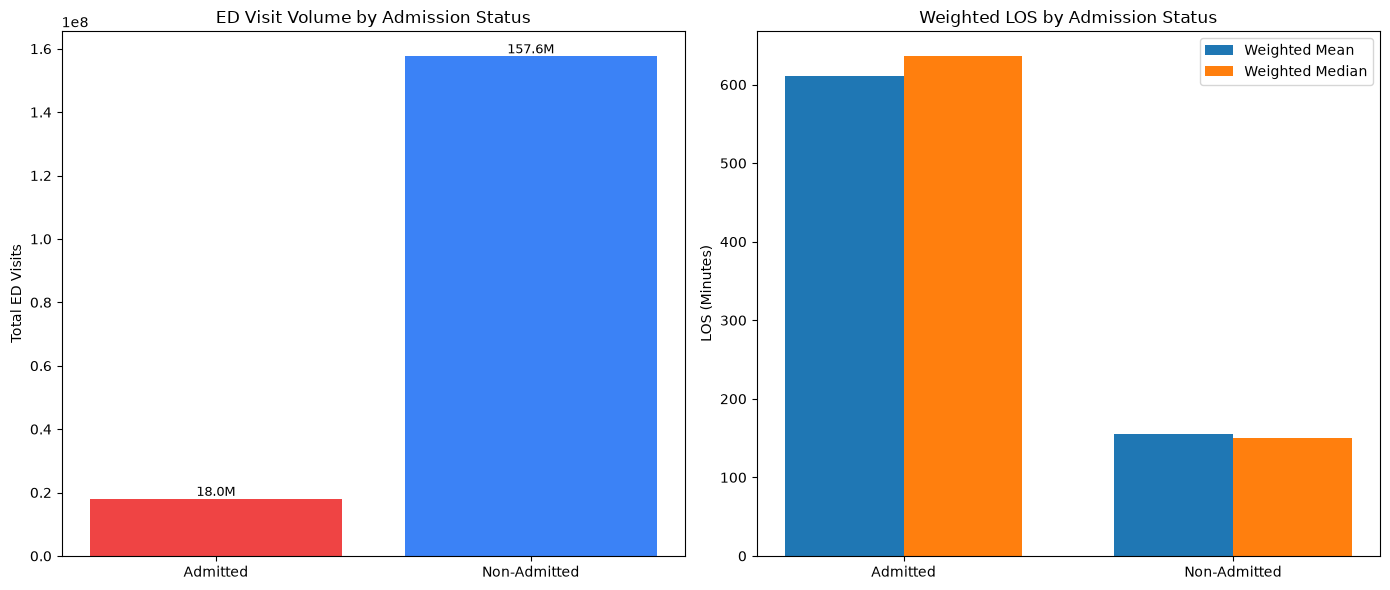

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(h2_summary["group"], h2_summary["total_ed_visits"], color=["#EF4444", "#3B82F6"])
axes[0].set_ylabel("Total ED Visits")
axes[0].set_title("ED Visit Volume by Admission Status")
for i, v in enumerate(h2_summary["total_ed_visits"]):
    axes[0].text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

x = np.arange(2)
width = 0.36
axes[1].bar(x - width / 2, h2_summary["weighted_mean_los_minutes"], width, label="Weighted Mean")
axes[1].bar(x + width / 2, h2_summary["weighted_median_los_minutes"], width, label="Weighted Median")
axes[1].set_xticks(x)
axes[1].set_xticklabels(h2_summary["group"])
axes[1].set_ylabel("LOS (Minutes)")
axes[1].set_title("Weighted LOS by Admission Status")
axes[1].legend()

plt.tight_layout()
plt.show()

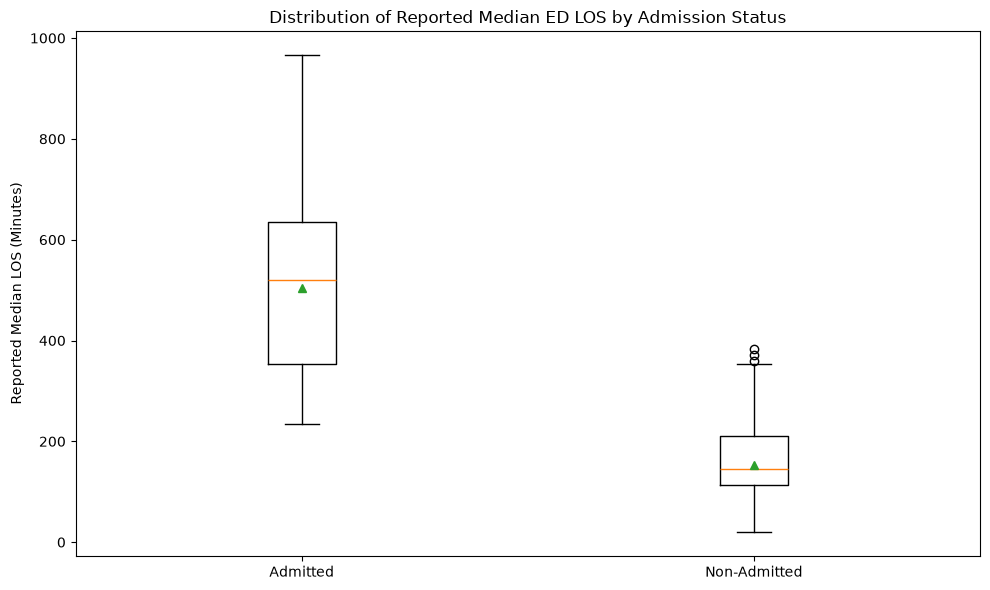

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot([np.array(a_vals), np.array(n_vals)],
           tick_labels=["Admitted", "Non-Admitted"], showmeans=True)
ax.set_ylabel("Reported Median LOS (Minutes)")
ax.set_title("Distribution of Reported Median ED LOS by Admission Status")

plt.tight_layout()
plt.show()

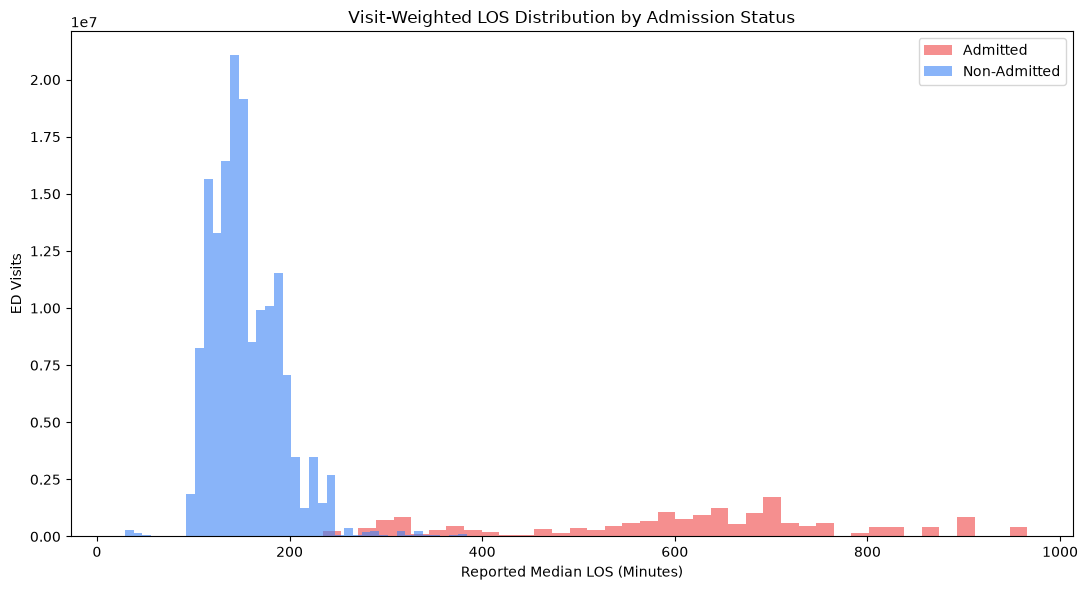

In [17]:
# Weighted LOS distribution: each aggregate row contributes in proportion to its visits.
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(a_vals, bins=40, weights=a_wts, alpha=0.6, label="Admitted", color="#EF4444")
ax.hist(n_vals, bins=40, weights=n_wts, alpha=0.6, label="Non-Admitted", color="#3B82F6")

ax.set_xlabel("Reported Median LOS (Minutes)")
ax.set_ylabel("ED Visits")
ax.set_title("Visit-Weighted LOS Distribution by Admission Status")
ax.legend()

plt.tight_layout()
plt.show()

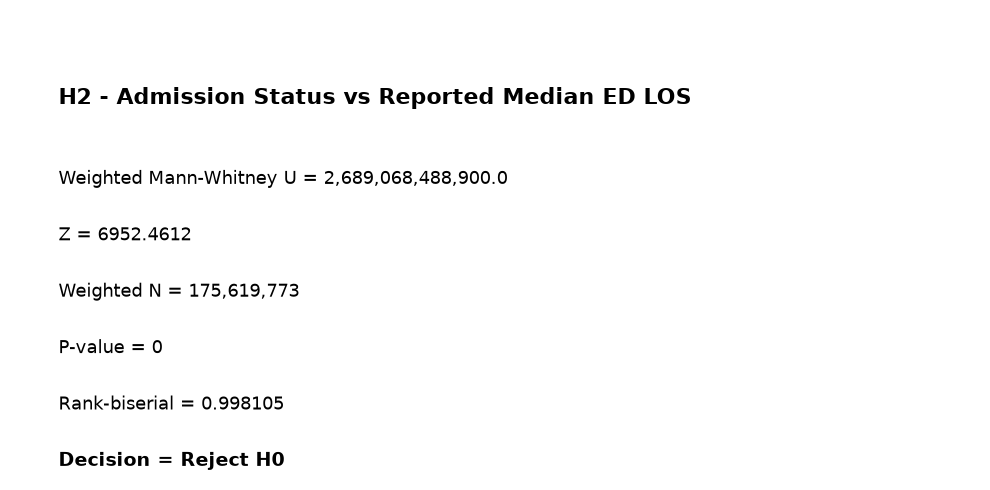

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

decision = "Reject H0" if p_value < ALPHA else "Fail to Reject H0"

ax.text(0.05, 0.80, "H2 - Admission Status vs Reported Median ED LOS",
        fontsize=16, fontweight="bold")
ax.text(0.05, 0.63, f"Weighted Mann-Whitney U = {h2_result['u_statistic']:,.1f}", fontsize=13)
ax.text(0.05, 0.51, f"Z = {h2_result['z_score']:.4f}", fontsize=13)
ax.text(0.05, 0.39, f"Weighted N = {h2_result['weighted_n']:,}", fontsize=13)
ax.text(0.05, 0.27, f"P-value = {p_value:.6g}", fontsize=13)
ax.text(0.05, 0.15, f"Rank-biserial = {rb:.6f}", fontsize=13)
ax.text(0.05, 0.03, f"Decision = {decision}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [19]:
from backend.analytics.hypothesis_testing import run_h2_test

api = run_h2_test()

print("NOTEBOOK vs PRODUCTION ENGINE")
print("=" * 80)
print(f"{'metric':22} {'notebook':>22} {'backend':>22}")
print(f"{'U':22} {h2_result['u_statistic']:>22,.1f} {api['u_statistic']:>22,.1f}")
print(f"{'weighted N':22} {h2_result['weighted_n']:>22,} {api['weighted_n']:>22,}")
print(f"{'rank biserial':22} {rb:>22.6f} {api['rank_biserial']:>22.6f}")
print(f"{'decision':22} {decision:>22} {api['decision']:>22}")
print()
print("Note: the backend reads the analytical database (built from the cleaned master")
print("workbook) while this notebook reads the Explorer CSV, so the two can differ")
print("slightly in row coverage. The METHOD is identical.")

NOTEBOOK vs PRODUCTION ENGINE
metric                               notebook                backend
U                         2,689,068,488,900.0    2,689,068,488,900.0
weighted N                        175,619,773            175,619,773
rank biserial                        0.998105               0.998105
decision                            Reject H0              Reject H₀

Note: the backend reads the analytical database (built from the cleaned master
workbook) while this notebook reads the Explorer CSV, so the two can differ
slightly in row coverage. The METHOD is identical.
